# CALVIN Automaton Sample-And-Rank

This notebook mirrors the toy-squares automaton-guidance notebook, but keeps the Calvin rollout / behavior-classification structure from `env_playground.ipynb`. It only runs unguided rollout and sample-and-rank; no gradient guidance.


In [1]:
# imports and notebook setup
from pathlib import Path
from collections import Counter
import importlib
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import numpy as np
import torch

REPO_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "calvin_experiments" / "calvin_rollout_utils.py").exists()
)
for path in [REPO_ROOT, REPO_ROOT / "robomimic", REPO_ROOT / "calvin" / "calvin_env", REPO_ROOT / "calvin_experiments"]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import robomimic.envs
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils
import robomimic.utils.torch_utils as TorchUtils

import calvin_experiments.calvin_rollout_utils as CalvinRolloutUtils
from calvin_experiments.label_calvin_world_model import label_scene_states_for_names

CalvinRolloutUtils = importlib.reload(CalvinRolloutUtils)
from calvin_experiments.calvin_rollout_utils import (
    articulated_binaries_from_start_state,
    automaton_model_for_eval,
    capture_scene_snapshot,
    check_state_difference,
    close_env_quietly,
    drop_env_quietly,
    classify_behavior,
    fixed_scene_robot_from_config,
    load_fresh_env_from_checkpoint,
    format_onehot,
    format_probs,
    load_json_config,
    policy_epoch_from_checkpoint,
    plot_rollout_xy,
    render_visual_camera,
    run_folder_name,
    reset_env_to_scene_robot,
    resolve_checkpoint_path,
    save_rollout_artifacts,
    seed_everything,
    to_numpy,
)

CONFIG_DIR = REPO_ROOT / "calvin_experiments" / "configs"
SCENE_CONFIG_PATH = CONFIG_DIR / "blocks_hidden.json"
VISUALIZATION_CONFIG_PATH = CONFIG_DIR / "visualization_freiburg_style.json"
CHECKPOINT_PATH = REPO_ROOT / "outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth"
OUTPUT_ROOT = REPO_ROOT / "outputs/calvin/guidance_test"
VIDEO_FPS = 30

# AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_next_tH_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_22-21-01"
AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38"
# AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_sh64_ah96_lh8_hh96_lr0.0001_epochs80_2026-05-04_17-15-26"
# AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_sh64_ah96_lh8_hh96_lr0.0003_epochs80_2026-05-05_19-25-09"
SCENE_CONFIG_NAME = load_json_config(SCENE_CONFIG_PATH)["name"]


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# load policy, environment, and automaton models
checkpoint_path = resolve_checkpoint_path(CHECKPOINT_PATH, REPO_ROOT)
POLICY_EPOCH = policy_epoch_from_checkpoint(checkpoint_path)
if not AUTOMATON_CKPT_PATH.exists():
    raise FileNotFoundError(f"Automaton checkpoint not found: {AUTOMATON_CKPT_PATH}")

device = TorchUtils.get_torch_device(try_to_use_cuda=True)
policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=str(checkpoint_path), device=device, verbose=False)
drop_env_quietly(globals())
env, base_env_state = load_fresh_env_from_checkpoint(ckpt_dict, suppress_output=True)

automaton_model, automaton_stats, automaton_meta = automaton_model_for_eval(AUTOMATON_CKPT_PATH, device)
AUTOMATON_LABEL_NAMES = list(automaton_meta["label_names"])
AUTOMATON_LABEL_THRESHOLDS = automaton_meta.get("label_thresholds")
TARGET_INDEX_MAPPING = {idx: name for idx, name in enumerate(AUTOMATON_LABEL_NAMES)}


def print_target_index_mapping():
    print("Target index mapping for loaded automaton model:")
    for idx, name in TARGET_INDEX_MAPPING.items():
        print(f"  {idx}: {name}")


def validate_target_label_idx(target_label_idx):
    target_label_idx = int(target_label_idx)
    if target_label_idx not in TARGET_INDEX_MAPPING:
        raise ValueError(
            f"target_label_idx must be in [0, {len(AUTOMATON_LABEL_NAMES) - 1}], got {target_label_idx}"
        )
    return target_label_idx


OPPOSITE_LABEL_NAMES = {
    "switch_on": "switch_off",
    "switch_off": "switch_on",
    "button_on": "button_off",
    "button_off": "button_on",
    "drawer_open": "drawer_closed",
    "drawer_closed": "drawer_open",
    "door_left": "door_right",
    "door_right": "door_left",
}


def opposite_label_idx(target_label_idx):
    target_label_idx = validate_target_label_idx(target_label_idx)
    opposite_name = OPPOSITE_LABEL_NAMES.get(AUTOMATON_LABEL_NAMES[target_label_idx])
    if opposite_name is None or opposite_name not in AUTOMATON_LABEL_NAMES:
        return None
    return AUTOMATON_LABEL_NAMES.index(opposite_name)


def score_label_probs(label_probs, target_label_idx):
    target_label_idx = validate_target_label_idx(target_label_idx)
    scores = np.asarray(label_probs, dtype=np.float32)[..., target_label_idx].copy()
    opposite_idx = opposite_label_idx(target_label_idx)
    if opposite_idx is not None:
        scores -= np.asarray(label_probs, dtype=np.float32)[..., opposite_idx]
    return scores


def score_rule_name(target_label_idx):
    target_label_idx = validate_target_label_idx(target_label_idx)
    opposite_idx = opposite_label_idx(target_label_idx)
    target_name = AUTOMATON_LABEL_NAMES[target_label_idx]
    if opposite_idx is None:
        return f"p({target_name})"
    return f"p({target_name}) - p({AUTOMATON_LABEL_NAMES[opposite_idx]})"


print("Loaded policy:", checkpoint_path)
print("Policy epoch:", POLICY_EPOCH)
print("Loaded automaton:", automaton_meta["ckpt_path"])
print("Automaton config:", automaton_meta["model_config"])
print("Label order:", AUTOMATON_LABEL_NAMES)
print_target_index_mapping()
print("Known opposites:", {name: other for name, other in OPPOSITE_LABEL_NAMES.items() if name in AUTOMATON_LABEL_NAMES and other in AUTOMATON_LABEL_NAMES})
print("Device:", device)



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['proprio']
using obs modality: rgb with keys: ['eye_in_hand', 'third_person']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.931892e+07
Loaded policy: /home/moritz/src/guided-diffusion/outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth
Policy epoch: epoch280
Loaded automaton: /home/moritz/src/guided-diffusion/outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38/best_model.pt
Automaton config: {'state_dim': 39, 'label_dim': 9, 'action_chunk_dim': 56, 'state_hidden': 64, 'label_hidden': 16, 'action_hidden': 96, 'head_hidden': 128, 'dropout': 0.15}
Label order: ['switch_on', 'switch_off', 'button_on', 'button_off', 'button_pressed', 'drawer_open', 'drawer_closed', 'door_left', 'door_right']
Target index mapping for loaded automaton model:
  0

In [3]:
# rollout behavior helper functions
def current_automaton_state_and_labels(env):
    state = env.get_state()
    robot = np.asarray(state["robot"], dtype=np.float32).reshape(-1)
    scene = np.asarray(state["scene"], dtype=np.float32).reshape(-1)
    automaton_state = np.concatenate([robot, scene]).astype(np.float32)
    automaton_label = label_scene_states_for_names(
        scene[None, :], AUTOMATON_LABEL_NAMES, AUTOMATON_LABEL_THRESHOLDS
    )[0].astype(np.float32)
    return automaton_state, automaton_label


current_automaton_state_and_label = current_automaton_state_and_labels


def rollout_policy_once(
    seed=2,
    horizon=100,
    stop_on_behavior=True,
    action_provider=None,
    output_dir=None,
    rollout_tag=None,
    save_video=True,
    video_cfg=None,
):
    global env, base_env_state
    drop_env_quietly(globals())
    env, base_env_state = load_fresh_env_from_checkpoint(
        ckpt_dict,
        seed=seed,
        suppress_output=True,
    )
    fixed_scene, fixed_robot, scene_cfg = fixed_scene_robot_from_config(base_env_state, SCENE_CONFIG_PATH)

    seed_everything(seed)
    policy.start_episode()
    obs = reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
    scene_snapshot = capture_scene_snapshot(env)

    should_save = output_dir is not None and bool(save_video)
    if should_save and video_cfg is None:
        video_cfg = load_json_config(VISUALIZATION_CONFIG_PATH)
    frames = [render_visual_camera(env, video_cfg)] if should_save else []

    start_state = env.get_state()
    start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
    binaries = articulated_binaries_from_start_state(start_scene)
    state0, label0 = current_automaton_state_and_labels(env)

    actions, rewards, dones = [], [], []
    scene_states = [start_scene.copy()]
    robot_states = [np.asarray(start_state["robot"], dtype=np.float32).copy()]
    eef_xy = [robot_states[-1][:2].copy()]
    records = []

    detected_behavior = "none"
    detected_step = -1
    termination_reason = "horizon"
    action_queue = []

    for step in range(int(horizon)):
        if action_provider is None:
            action = policy(ob=obs)
        else:
            if not action_queue:
                new_actions, record = action_provider(obs, env, step)
                action_queue.extend(np.asarray(new_actions, dtype=np.float32))
                records.append(record)
            action = action_queue.pop(0)

        action_to_step = np.asarray(action, dtype=np.float32).copy()
        actions.append(action_to_step.copy())
        obs, reward, done, info = env.step(action_to_step)
        state = env.get_state()
        scene = np.asarray(state["scene"], dtype=np.float32).copy()
        robot = np.asarray(state["robot"], dtype=np.float32).copy()

        rewards.append(float(reward))
        dones.append(bool(done))
        scene_states.append(scene)
        robot_states.append(robot)
        eef_xy.append(robot[:2].copy())
        if should_save:
            frames.append(render_visual_camera(env, video_cfg))

        triggered = check_state_difference(start_scene, scene, robot[:3], binaries, for_display=False)
        if detected_step < 0 and triggered:
            detected_behavior = classify_behavior(start_scene, scene, robot[:3], binaries, for_display=False)
            detected_step = step + 1
            if stop_on_behavior:
                termination_reason = "behavior"
                break
        if done:
            termination_reason = "env_done"
            break

    statef, labelf = current_automaton_state_and_labels(env)
    rollout = {
        "scene_config": scene_cfg["name"],
        "seed": int(seed),
        "behavior": detected_behavior,
        "behavior_step": int(detected_step),
        "termination_step": len(actions),
        "termination_reason": termination_reason,
        "return": float(np.sum(rewards)),
        "actions": np.asarray(actions, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=bool),
        "scene_states": np.asarray(scene_states, dtype=np.float32),
        "robot_states": np.asarray(robot_states, dtype=np.float32),
        "eef_xy": np.asarray(eef_xy, dtype=np.float32),
        "initial_label": label0.astype(int).tolist(),
        "final_label": labelf.astype(int).tolist(),
        "records": records,
        "scene_snapshot": scene_snapshot,
    }
    if should_save:
        if rollout_tag is None:
            rollout_tag = f"rollout_seed_{int(seed):03d}"
        save_rollout_artifacts(rollout, frames, output_dir, rollout_tag, video_cfg, fps=VIDEO_FPS)
    return rollout


ven = NVIDIA Corporation
ven = NVIDIA Corporation


/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'dict'>`
  logger.warn(


ObservationKeyToModalityDict: states not found, adding states to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: timesteps not found, adding timesteps to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: actions not found, adding actions to mapping with assumed low_dim modality!


/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:225: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:137: UserWarning: WARN: The obs returned by the `step()` method was expecting a numpy array, actual type: <class 'dict'>
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/spaces/box.py:227: UserWarning: WARN: Casting input x to numpy array.
  logger.warn("Cas

Unguided rollout seed=7: behavior=button_on @ 42, steps=42 (behavior), return=0.000
initial automaton label: [0 1 0 1 0 0 1 0 1] final: [0 1 1 0 0 0 1 0 1]
video: /home/moritz/src/guided-diffusion/outputs/calvin/guidance_test/unguided_policy_epoch280_scene_blocks_hidden_rollouts1_horizon100_seed7_05-05-26__23-21-46/rollout_000/blocks_hidden_rollout_000_freiburg_style.mp4
trace: /home/moritz/src/guided-diffusion/outputs/calvin/guidance_test/unguided_policy_epoch280_scene_blocks_hidden_rollouts1_horizon100_seed7_05-05-26__23-21-46/rollout_000/rollout_trace.npz
plot: /home/moritz/src/guided-diffusion/outputs/calvin/guidance_test/unguided_policy_epoch280_scene_blocks_hidden_rollouts1_horizon100_seed7_05-05-26__23-21-46/rollout_xy.png


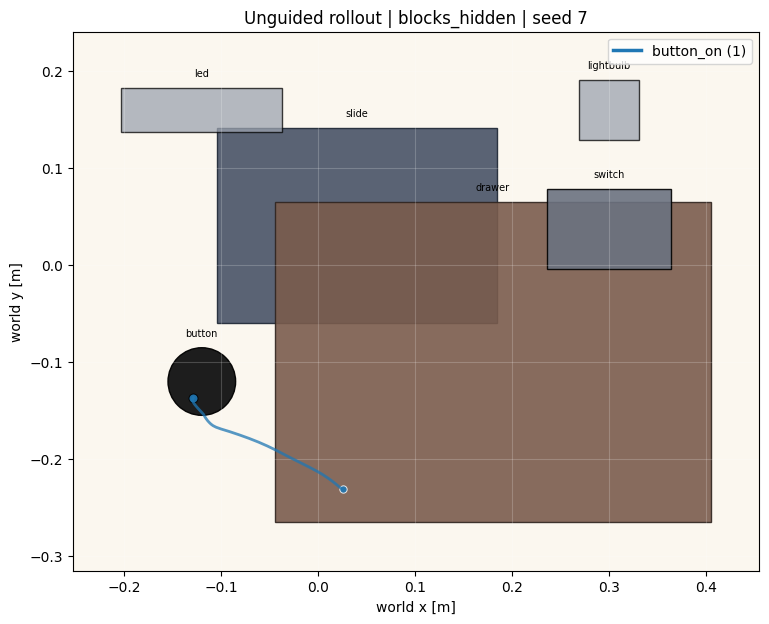

In [4]:
# run one rollout and plot xy
UNGUIDED_SEED = 7
UNGUIDED_HORIZON = 100

unguided_output_dir = OUTPUT_ROOT / run_folder_name(
    "unguided",
    f"policy_{POLICY_EPOCH}",
    f"scene_{SCENE_CONFIG_NAME}",
    "rollouts1",
    f"horizon{UNGUIDED_HORIZON}",
    f"seed{UNGUIDED_SEED}",
)
unguided_rollout = rollout_policy_once(
    seed=UNGUIDED_SEED,
    horizon=UNGUIDED_HORIZON,
    stop_on_behavior=True,
    output_dir=unguided_output_dir,
    rollout_tag="rollout_000",
)
print(
    f"Unguided rollout seed={UNGUIDED_SEED}: behavior={unguided_rollout['behavior']} "
    f"@ {unguided_rollout['behavior_step']}, steps={unguided_rollout['termination_step']} "
    f"({unguided_rollout['termination_reason']}), return={unguided_rollout['return']:.3f}"
)
print("initial automaton label:", format_onehot(unguided_rollout["initial_label"]), "final:", format_onehot(unguided_rollout["final_label"]))
print("video:", unguided_rollout.get("video"))
print("trace:", unguided_rollout.get("trace"))
plot_rollout_xy(
    [unguided_rollout],
    unguided_rollout["scene_snapshot"],
    f"Unguided rollout | {unguided_rollout['scene_config']} | seed {UNGUIDED_SEED}",
    save_path=unguided_output_dir / "rollout_xy.png",
)



In [5]:
# sample and rank rollout helper functions
def _repeat_obs_batch(obs_tensor, n):
    if n == 1:
        return obs_tensor
    return {key: value.repeat((n,) + (1,) * (value.ndim - 1)) for key, value in obs_tensor.items()}


def _unnormalize_action_sequence(action_sequence):
    action_np = to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np

    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {key: policy.action_normalization_stats[key]["offset"].shape[1:] for key in policy.action_normalization_stats}
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)


def predict_future_label_probs(automaton_state, automaton_label, action_chunks):
    action_chunks = np.asarray(action_chunks, dtype=np.float32)
    if action_chunks.ndim != 3:
        raise ValueError(f"Expected action_chunks shape (N, H, A), got {action_chunks.shape}")

    n_candidates, _, action_dim = action_chunks.shape
    state_dim = len(automaton_stats["states_mean"])
    action_chunk_dim = len(automaton_stats["actions_mean"])
    if len(automaton_state) != state_dim:
        raise ValueError(f"Automaton state dim mismatch: rollout has {len(automaton_state)}, checkpoint expects {state_dim}.")
    if action_chunk_dim % action_dim != 0:
        raise ValueError(f"Automaton action chunk dim {action_chunk_dim} is not divisible by action dim {action_dim}")
    automaton_horizon = action_chunk_dim // action_dim
    if action_chunks.shape[1] < automaton_horizon:
        raise ValueError(f"Policy produced {action_chunks.shape[1]} actions, automaton expects horizon {automaton_horizon}")

    scored_chunks = action_chunks[:, :automaton_horizon, :].reshape(n_candidates, -1)
    states = np.repeat(np.asarray(automaton_state, dtype=np.float32)[None, :], n_candidates, axis=0)
    labels = np.repeat(np.asarray(automaton_label, dtype=np.float32)[None, :], n_candidates, axis=0)

    states_t = torch.as_tensor((states - automaton_stats["states_mean"]) / automaton_stats["states_std"], device=device, dtype=torch.float32)
    actions_t = torch.as_tensor((scored_chunks - automaton_stats["actions_mean"]) / automaton_stats["actions_std"], device=device, dtype=torch.float32)
    labels_t = torch.as_tensor(labels, device=device, dtype=torch.float32)
    with torch.no_grad():
        return torch.sigmoid(automaton_model(states_t, actions_t, labels_t)).detach().cpu().numpy(), automaton_horizon


def make_sample_rank_action_provider(target_label_idx, n_candidates):
    target_label_idx = int(target_label_idx)
    n_candidates = int(n_candidates)
    if target_label_idx < 0 or target_label_idx >= len(AUTOMATON_LABEL_NAMES):
        raise ValueError(f"target_label_idx must be in [0, {len(AUTOMATON_LABEL_NAMES) - 1}], got {target_label_idx}")
    if n_candidates < 1:
        raise ValueError("n_candidates must be >= 1")

    def action_provider(obs, env, step):
        automaton_state, automaton_label = current_automaton_state_and_labels(env)
        obs_tensor = policy._prepare_observation(obs)
        obs_tensor_rank = _repeat_obs_batch(obs_tensor, n_candidates)
        with torch.no_grad():
            action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
        action_chunk = _unnormalize_action_sequence(action_chunk_n)
        candidate_probs, automaton_horizon = predict_future_label_probs(automaton_state, automaton_label, action_chunk)
        candidate_scores = score_label_probs(candidate_probs, target_label_idx)
        opposite_idx = opposite_label_idx(target_label_idx)
        selected_idx = int(np.argmax(candidate_scores))
        record = {
            "t": int(step),
            "target_label_idx": target_label_idx,
            "target_label_name": AUTOMATON_LABEL_NAMES[target_label_idx],
            "opposite_label_idx": None if opposite_idx is None else int(opposite_idx),
            "opposite_label_name": None if opposite_idx is None else AUTOMATON_LABEL_NAMES[opposite_idx],
            "score_rule": score_rule_name(target_label_idx),
            "current_label": automaton_label.astype(int).tolist(),
            "selected_idx": selected_idx,
            "selected_score": float(candidate_scores[selected_idx]),
            "selected_target_prob": float(candidate_probs[selected_idx, target_label_idx]),
            "selected_opposite_prob": None if opposite_idx is None else float(candidate_probs[selected_idx, opposite_idx]),
            "pred_probs": candidate_probs[selected_idx].tolist(),
            "candidate_scores": candidate_scores.tolist(),
        }
        return action_chunk[selected_idx, :automaton_horizon, :], record

    return action_provider


Target index mapping for loaded automaton model:
  0: switch_on
  1: switch_off
  2: button_on
  3: button_off
  4: button_pressed
  5: drawer_open
  6: drawer_closed
  7: door_left
  8: door_right
ven = NVIDIA Corporation
ven = NVIDIA Corporation
Sample-and-rank target=0 (switch_on), N=16
Score rule: p(switch_on) - p(switch_off)
Rollout: behavior=switch_on @ 54, steps=54 (behavior), return=0.000, final_label=[1 0 0 1 0 0 1 0 1]
video: /home/moritz/src/guided-diffusion/outputs/calvin/guidance_test/sample_rank_policy_epoch280_scene_blocks_hidden_rollouts1_target0_candidates16_horizon100_seed7_05-05-26__23-21-48/rollout_000/blocks_hidden_rollout_000_freiburg_style.mp4
trace: /home/moritz/src/guided-diffusion/outputs/calvin/guidance_test/sample_rank_policy_epoch280_scene_blocks_hidden_rollouts1_target0_candidates16_horizon100_seed7_05-05-26__23-21-48/rollout_000/rollout_trace.npz
   t  pick    score    p_tgt    p_opp    current             pred_future_prob
   0    14   -0.862    0.074    

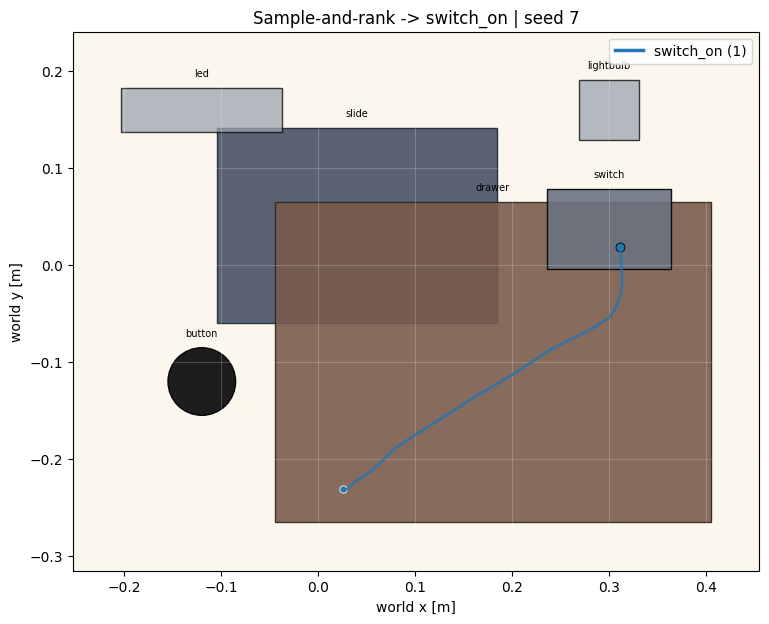

In [6]:
# run sample and rank rollout
# Target indices come from TARGET_INDEX_MAPPING printed after loading the automaton model.
TARGET_LABEL_IDX = 0 
print_target_index_mapping()
TARGET_LABEL_IDX = validate_target_label_idx(TARGET_LABEL_IDX)
SAMPLE_AND_RANK_N = 16
SAMPLE_AND_RANK_SEED = 7
SAMPLE_AND_RANK_HORIZON = 100

sample_rank_output_dir = OUTPUT_ROOT / run_folder_name(
    "sample_rank",
    f"policy_{POLICY_EPOCH}",
    f"scene_{SCENE_CONFIG_NAME}",
    "rollouts1",
    f"target{TARGET_LABEL_IDX}",
    f"candidates{SAMPLE_AND_RANK_N}",
    f"horizon{SAMPLE_AND_RANK_HORIZON}",
    f"seed{SAMPLE_AND_RANK_SEED}",
)
sample_rank_action_provider = make_sample_rank_action_provider(TARGET_LABEL_IDX, SAMPLE_AND_RANK_N)
sample_rank_rollout = rollout_policy_once(
    seed=SAMPLE_AND_RANK_SEED,
    horizon=SAMPLE_AND_RANK_HORIZON,
    stop_on_behavior=True,
    action_provider=sample_rank_action_provider,
    output_dir=sample_rank_output_dir,
    rollout_tag="rollout_000",
)

print(f"Sample-and-rank target={TARGET_LABEL_IDX} ({AUTOMATON_LABEL_NAMES[TARGET_LABEL_IDX]}), N={SAMPLE_AND_RANK_N}")
print("Score rule:", score_rule_name(TARGET_LABEL_IDX))
print(
    f"Rollout: behavior={sample_rank_rollout['behavior']} @ {sample_rank_rollout['behavior_step']}, "
    f"steps={sample_rank_rollout['termination_step']} ({sample_rank_rollout['termination_reason']}), "
    f"return={sample_rank_rollout['return']:.3f}, final_label={format_onehot(sample_rank_rollout['final_label'])}"
)
print("video:", sample_rank_rollout.get("video"))
print("trace:", sample_rank_rollout.get("trace"))
print(f"{'t':>4}  {'pick':>4}  {'score':>7}  {'p_tgt':>7}  {'p_opp':>7}  {'current':>9}  {'pred_future_prob':>27}")
for record in sample_rank_rollout["records"]:
    p_opp = "   n/a" if record["selected_opposite_prob"] is None else f"{record['selected_opposite_prob']:7.3f}"
    print(
        f"{record['t']:4d}  {record['selected_idx']:4d}  {record['selected_score']:7.3f}  "
        f"{record['selected_target_prob']:7.3f}  {p_opp}  "
        f"{format_onehot(record['current_label']):>9}  {format_probs(record['pred_probs']):>27}"
    )
plot_rollout_xy(
    [sample_rank_rollout],
    sample_rank_rollout["scene_snapshot"],
    f"Sample-and-rank -> {AUTOMATON_LABEL_NAMES[TARGET_LABEL_IDX]} | seed {SAMPLE_AND_RANK_SEED}",
    save_path=sample_rank_output_dir / "rollout_xy.png",
)


In [7]:
# sample and rank batch helper functions
def run_sample_rank_batch(target_label_idx, n_rollouts=20, seed_start=0, seeds=None, n_candidates=16, horizon=100):
    target_label_idx = int(target_label_idx)
    if seeds is None:
        seeds = list(range(int(seed_start), int(seed_start) + int(n_rollouts)))
    else:
        seeds = [int(seed) for seed in seeds]

    run_dir = OUTPUT_ROOT / run_folder_name(
        "sample_rank_batch",
        f"policy_{POLICY_EPOCH}",
        f"scene_{SCENE_CONFIG_NAME}",
        f"rollouts{len(seeds)}",
        f"target{target_label_idx}",
        f"candidates{int(n_candidates)}",
        f"horizon{int(horizon)}",
    )
    run_dir.mkdir(parents=True, exist_ok=True)
    video_cfg = load_json_config(VISUALIZATION_CONFIG_PATH)

    action_provider = make_sample_rank_action_provider(target_label_idx, n_candidates)
    rollouts = []
    for rollout_idx, seed in enumerate(seeds):
        rollout = rollout_policy_once(
            seed=seed,
            horizon=horizon,
            stop_on_behavior=True,
            action_provider=action_provider,
            output_dir=run_dir,
            rollout_tag=f"rollout_{rollout_idx:03d}_seed_{seed:03d}",
            video_cfg=video_cfg,
        )
        rollouts.append(rollout)
        print(
            f"seed {seed:03d} -> behavior={rollout['behavior']:>12} "
            f"@ {rollout['behavior_step']:>3}, steps={rollout['termination_step']:>3}, "
            f"final_label={format_onehot(rollout['final_label'])}, video={rollout['video']}"
        )

    behavior_counts = Counter(rollout["behavior"] for rollout in rollouts)
    final_label_counts = Counter(tuple(rollout["final_label"]) for rollout in rollouts)

    print("\nBehavior split:")
    for behavior, count in behavior_counts.most_common():
        print(f"  {behavior:>12}: {count:>3}/{len(rollouts)} ({count / len(rollouts):.1%})")

    print("\nFinal label split:")
    for label, count in final_label_counts.most_common():
        print(f"  {format_onehot(label)}: {count:>3}/{len(rollouts)} ({count / len(rollouts):.1%})")

    summary = {
        "target_label_idx": target_label_idx,
        "target_label_name": AUTOMATON_LABEL_NAMES[target_label_idx],
        "opposite_label_idx": opposite_label_idx(target_label_idx),
        "opposite_label_name": None if opposite_label_idx(target_label_idx) is None else AUTOMATON_LABEL_NAMES[opposite_label_idx(target_label_idx)],
        "score_rule": score_rule_name(target_label_idx),
        "n_rollouts": len(rollouts),
        "n_candidates": int(n_candidates),
        "horizon": int(horizon),
        "seeds": seeds,
        "behavior_counts": dict(behavior_counts),
        "final_label_counts": {str(label): count for label, count in final_label_counts.items()},
        "rollouts": [
            {
                "seed": rollout["seed"],
                "behavior": rollout["behavior"],
                "behavior_step": rollout["behavior_step"],
                "termination_step": rollout["termination_step"],
                "termination_reason": rollout["termination_reason"],
                "return": rollout["return"],
                "initial_label": rollout["initial_label"],
                "final_label": rollout["final_label"],
                "video": str(rollout["video"]),
                "trace": str(rollout["trace"]),
            }
            for rollout in rollouts
        ],
    }
    summary_path = run_dir / "batch_summary.json"
    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    plot_rollout_xy(
        rollouts,
        rollouts[0]["scene_snapshot"],
        f"Sample-and-rank batch -> {AUTOMATON_LABEL_NAMES[target_label_idx]} | N={len(rollouts)}, candidates={n_candidates}",
        save_path=run_dir / "batch_rollout_xy.png",
    )
    print("\nOutput dir:", run_dir)
    print("Summary JSON:", summary_path)
    print("Score rule:", score_rule_name(target_label_idx))
    return rollouts, behavior_counts, final_label_counts, run_dir


Target index mapping for loaded automaton model:
  0: switch_on
  1: switch_off
  2: button_on
  3: button_off
  4: button_pressed
  5: drawer_open
  6: drawer_closed
  7: door_left
  8: door_right
ven = NVIDIA Corporation
ven = NVIDIA Corporation
seed 001 -> behavior=   door_left @ 205, steps=205, final_label=[0 1 0 1 0 0 1 0 1], video=/home/moritz/src/guided-diffusion/outputs/calvin/guidance_test/sample_rank_batch_policy_epoch280_scene_blocks_hidden_rollouts10_target5_candidates1_horizon500_05-05-26__23-27-35/rollout_000_seed_001/blocks_hidden_rollout_000_seed_001_freiburg_style.mp4
ven = NVIDIA Corporation
ven = NVIDIA Corporation
seed 002 -> behavior= drawer_open @  63, steps= 63, final_label=[0 1 0 1 0 0 1 0 1], video=/home/moritz/src/guided-diffusion/outputs/calvin/guidance_test/sample_rank_batch_policy_epoch280_scene_blocks_hidden_rollouts10_target5_candidates1_horizon500_05-05-26__23-27-35/rollout_001_seed_002/blocks_hidden_rollout_001_seed_002_freiburg_style.mp4
ven = NVIDIA C

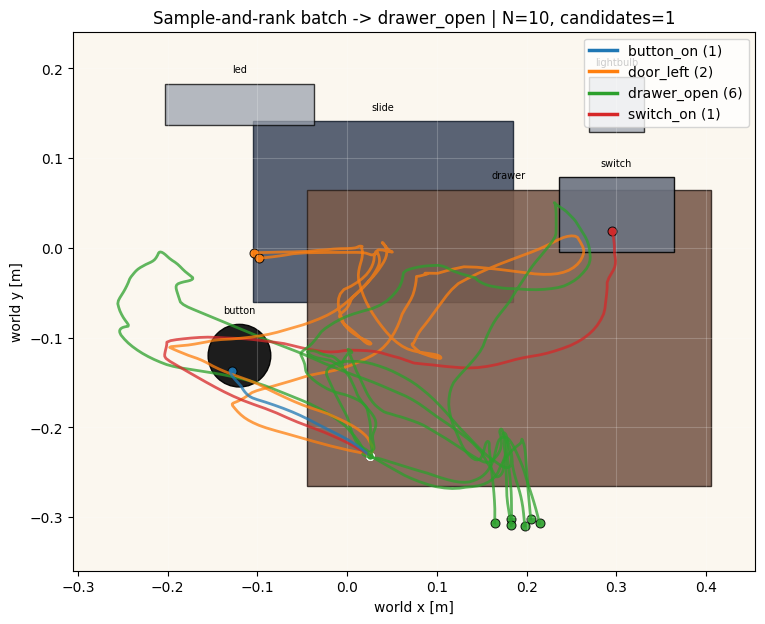


Output dir: /home/moritz/src/guided-diffusion/outputs/calvin/guidance_test/sample_rank_batch_policy_epoch280_scene_blocks_hidden_rollouts10_target5_candidates1_horizon500_05-05-26__23-27-35
Summary JSON: /home/moritz/src/guided-diffusion/outputs/calvin/guidance_test/sample_rank_batch_policy_epoch280_scene_blocks_hidden_rollouts10_target5_candidates1_horizon500_05-05-26__23-27-35/batch_summary.json
Score rule: p(drawer_open) - p(drawer_closed)


In [13]:
# run sample and rank batch
# Target indices come from TARGET_INDEX_MAPPING printed after loading the automaton model.
BATCH_TARGET_LABEL_IDX = 5
print_target_index_mapping()
BATCH_TARGET_LABEL_IDX = validate_target_label_idx(BATCH_TARGET_LABEL_IDX)
BATCH_N_ROLLOUTS = 10
# Keep this aligned with env_playground.GLOBAL_SEED when comparing N=1/no-guidance baselines.
BATCH_SEED_START = 1
BATCH_SEEDS = None  # Optional: set e.g. [2, 3, 7, 11] instead of using BATCH_SEED_START/BATCH_N_ROLLOUTS.
BATCH_SAMPLE_AND_RANK_N = 1
BATCH_HORIZON = 500

batch_sample_rank_rollouts, batch_behavior_counts, batch_final_label_counts, batch_output_dir = run_sample_rank_batch(
    target_label_idx=BATCH_TARGET_LABEL_IDX,
    n_rollouts=BATCH_N_ROLLOUTS,
    seed_start=BATCH_SEED_START,
    seeds=BATCH_SEEDS,
    n_candidates=BATCH_SAMPLE_AND_RANK_N,
    horizon=BATCH_HORIZON,
)


In [ ]:
# run sample and rank batch
# Target indices come from TARGET_INDEX_MAPPING printed after loading the automaton model.
BATCH_TARGET_LABEL_IDX = 0
print_target_index_mapping()
BATCH_TARGET_LABEL_IDX = validate_target_label_idx(BATCH_TARGET_LABEL_IDX)
BATCH_N_ROLLOUTS = 10
# Keep this aligned with env_playground.GLOBAL_SEED when comparing N=1/no-guidance baselines.
BATCH_SEED_START = 0
BATCH_SEEDS = None  # Optional: set e.g. [2, 3, 7, 11] instead of using BATCH_SEED_START/BATCH_N_ROLLOUTS.
BATCH_SAMPLE_AND_RANK_N = 16
BATCH_HORIZON = 100

batch_sample_rank_rollouts, batch_behavior_counts, batch_final_label_counts, batch_output_dir = run_sample_rank_batch(
    target_label_idx=BATCH_TARGET_LABEL_IDX,
    n_rollouts=BATCH_N_ROLLOUTS,
    seed_start=BATCH_SEED_START,
    seeds=BATCH_SEEDS,
    n_candidates=BATCH_SAMPLE_AND_RANK_N,
    horizon=BATCH_HORIZON,
)
